## **Setup**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]  # notebooks/ is one level down
sys.path.append(str(PROJECT_ROOT / "src"))

In [18]:
import time
import math
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import copy

# Local
from chatGnT.config import CFG, ensure_dirs
from chatGnT.data import load, preprocess, tokenize
from chatGnT.models import transformer, positional_encoding, train, evaluate, predict
import chatGnT.utils as utils

ensure_dirs(CFG)

## **Load & Clean Data**

In [4]:
data = load.load_all()
df = data["ingred"]
df_clean = preprocess.clean_recipes(df)
df_clean_filt = preprocess.filter_recipes(df_clean)


## **Make Vocab & Tokenize**

In [5]:

tokens = tokenize.recipe_to_tokens_2head(df_clean_filt)
print(tokens[0:2])


[[('<amt>1 oz</amt>', '<ingred>coconut-rum</ingred>'), ('<amt>0.5 oz</amt>', '<ingred>amaretto</ingred>'), ('<amt>4 oz</amt>', '<ingred>orange-juice</ingred>'), ('<amt>0.5 oz</amt>', '<ingred>grenadine</ingred>')], [('<amt>2 oz</amt>', '<ingred>light-rum</ingred>'), ('<amt>4 oz</amt>', '<ingred>ginger-beer</ingred>'), ('<amt>1 twist</amt>', '<ingred>lemon-peel</ingred>')]]


In [6]:
vocab_amt, vocab_ingred = tokenize.make_vocab_2head(tokens)
inv_vocab_amt, inv_vocab_ingred = tokenize.invert_vocab_2head(vocab_amt, vocab_ingred)
tokens_padded = tokenize.embed_tokens_2head(tokens, vocab_amt, vocab_ingred)


In [7]:
# Check vocab and padded tokens
print("Vocabulary:", vocab_amt)
print("Vocabulary:", vocab_ingred)
print("Padded Tokens:", tokens_padded[0:2])

Vocabulary: {'<amt>0.125 l</amt>': 1, '<amt>0.125 shot</amt>': 2, '<amt>0.125 tsp</amt>': 3, '<amt>0.16666666666666666 glass</amt>': 4, '<amt>0.2 part</amt>': 5, '<amt>0.25 cl</amt>': 6, '<amt>0.25 cup</amt>': 7, '<amt>0.25 glass</amt>': 8, '<amt>0.25 oz</amt>': 9, '<amt>0.25 part</amt>': 10, '<amt>0.25 shot</amt>': 11, '<amt>0.25 tsp</amt>': 12, '<amt>0.25</amt>': 13, '<amt>0.3333333333333333 cup</amt>': 14, '<amt>0.3333333333333333 oz</amt>': 15, '<amt>0.3333333333333333 part</amt>': 16, '<amt>0.3333333333333333 shot</amt>': 17, '<amt>0.4 part</amt>': 18, '<amt>0.5 can</amt>': 19, '<amt>0.5 cup</amt>': 20, '<amt>0.5 gal</amt>': 21, '<amt>0.5 glass</amt>': 22, '<amt>0.5 jigger</amt>': 23, '<amt>0.5 kg</amt>': 24, '<amt>0.5 l</amt>': 25, '<amt>0.5 lb</amt>': 26, '<amt>0.5 oz</amt>': 27, '<amt>0.5 part</amt>': 28, '<amt>0.5 piece</amt>': 29, '<amt>0.5 pint</amt>': 30, '<amt>0.5 shot</amt>': 31, '<amt>0.5 slice</amt>': 32, '<amt>0.5 tsp</amt>': 33, '<amt>0.5</amt>': 34, '<amt>0.666666666

In [8]:
amt_seqs, ingred_seqs = zip(*tokens_padded)  # unzip into two lists

# Convert to tensors
amt_tensor = torch.tensor(amt_seqs, dtype=torch.long)     # shape: (num_recipes, seq_len)
ingred_tensor = torch.tensor(ingred_seqs, dtype=torch.long)  # shape: (num_recipes, seq_len)

print(amt_tensor.shape, ingred_tensor.shape)

torch.Size([596, 13]) torch.Size([596, 13])


## **Get Batches**

In [9]:
# amt_tensor, ingred_tensor: shape (num_recipes, seq_len)
# For teacher forcing, inputs are all but last token, targets are all but first token
x_amt = amt_tensor[:, :-1]
y_amt = amt_tensor[:, 1:]

x_ingred = ingred_tensor[:, :-1]
y_ingred = ingred_tensor[:, 1:]

# Create a dataset of tuples: (x_amt, x_ingred, y_amt, y_ingred)
dataset = TensorDataset(x_amt, x_ingred, y_amt, y_ingred)

# Create DataLoader
dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print(dataloader.batch_size)  # 32
print(len(dataloader))        # ceil(num_recipes / batch_size)


32
19


## **Train Model**

In [19]:
embed_size=16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = transformer.TransformerModel2Head(
    ntoken_amt=len(vocab_amt),
    ntoken_ingred=len(vocab_ingred),
    ninp=embed_size,
    nhead=4,
    nhid=256,
    nlayers=2).to(device)
# Note warning:
# UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is
# False because encoder_layer.self_attn.batch_first was not True (use
# # batch_first for better inference performance)

pad_id_amt = vocab_amt["<pad>"]
pad_id_ingred = vocab_ingred["<pad>"]
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion_amt = torch.nn.CrossEntropyLoss(ignore_index=pad_id_amt)
criterion_ingred = torch.nn.CrossEntropyLoss(ignore_index=pad_id_ingred)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.95)
#TODO: read more about scheduler

/Users/slacksa/repos/chatGnT/src/chatGnT/models/transformer.py:8: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  


In [20]:
epochs = 100  # number of epochs

# Initialize trackers
train_losses = []
val_losses = []
best_val_loss = float("inf")
best_model = None

# Early Stopping parameters
patience = 5  # Stop if no improvement for 5 epochs
trigger_times = 0 

for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()

    avg_train_loss = train.train_2head(
        model,
        dataloader,
        device,
        pad_id_amt,
        pad_id_ingred,
        optimizer,
        criterion_amt,
        criterion_ingred,
        epoch,
        log_interval=6)
    train_losses.append(avg_train_loss)

    val_loss = evaluate.evaluate_2head(
        model,
        dataloader,
        device,
        pad_id_amt,
        pad_id_ingred,
        criterion_amt,
        criterion_ingred)
    val_losses.append(val_loss)

    print('-' * 89)
    print(
        f'Epoch {epoch} | Val Loss: {val_loss:.4f} | '
        f'Time {(time.time() - epoch_start_time)} | Val PPL: {math.exp(val_loss):.2f}')
    print('-' * 89)

    # 3. Early Stopping & Best Model Check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger_times = 0
        best_model = copy.deepcopy(model)
    else:
        trigger_times += 1
        print(f'No improvement. Early stopping counter: {trigger_times}/{patience}')
        if trigger_times >= patience:
            print("Early stopping triggered. Ending training.")
            break

    scheduler.step()  # adjusts learning rate
    #TODO: read more about this?


Epoch 1 | Batch 6 | LR 0.001000 | Loss 13.0944 | PPL 486196.50 | Time 0.08s
Epoch 1 | Batch 12 | LR 0.001000 | Loss 10.9980 | PPL 59757.32 | Time 0.05s
Epoch 1 | Batch 18 | LR 0.001000 | Loss 10.8293 | PPL 50478.20 | Time 0.05s
-----------------------------------------------------------------------------------------
Epoch 1 | Val Loss: 10.5578 | Time 0.21460509300231934 | Val PPL: 38476.76
-----------------------------------------------------------------------------------------
Epoch 2 | Batch 6 | LR 0.000950 | Loss 12.4032 | PPL 243586.56 | Time 0.06s
Epoch 2 | Batch 12 | LR 0.000950 | Loss 10.4985 | PPL 36261.68 | Time 0.06s
Epoch 2 | Batch 18 | LR 0.000950 | Loss 10.3153 | PPL 30189.99 | Time 0.05s
-----------------------------------------------------------------------------------------
Epoch 2 | Val Loss: 10.0547 | Time 0.2080068588256836 | Val PPL: 23265.73
-----------------------------------------------------------------------------------------
Epoch 3 | Batch 6 | LR 0.000902 | L

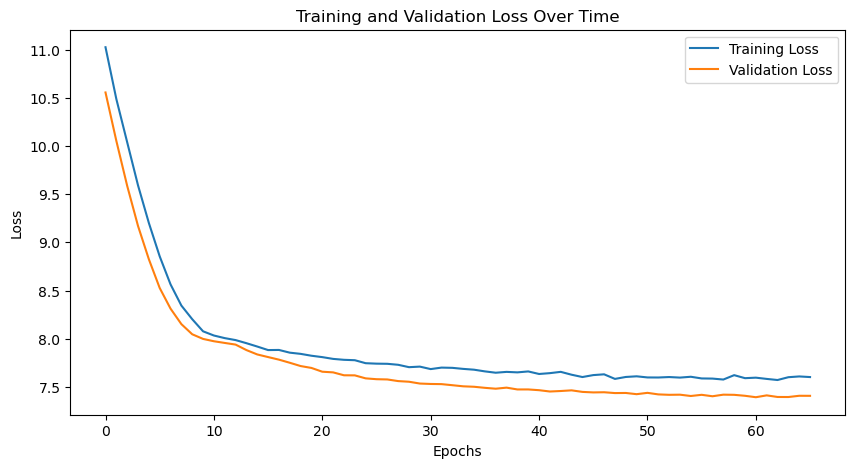

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.show()

## **Run with Test User Input**

In [22]:
#TODO: for now just manually making token, but need to handle actual format
# of user input
#TODO: write out best model, run this code/functions in another report
#TODO: switch to giving one recipe and having it predict another!

input_mod = [("<amt>1 oz</amt>", "<ingred>gin</ingred>")]

In [31]:

predict.predict_2head(best_model, device, pad_id_amt, pad_id_ingred, vocab_amt, vocab_ingred, inv_vocab_amt, inv_vocab_ingred, input_mod)


[('<amt>1 oz</amt>', '<ingred>gin</ingred>'),
 ('<amt>10 oz</amt>', '<ingred>vodka</ingred>'),
 ('<amt>0.5 shot</amt>', '<ingred>gin</ingred>'),
 ('<amt>3 cups</amt>', '<ingred>milk</ingred>'),
 ('<end>', '<end>')]